In [12]:
# Importar librerías
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [13]:
# Cargar archivos

df_hyp  = pd.read_csv('../datasets/hypotheses_us.csv', sep=';')
df_orders = pd.read_csv('../datasets/orders_us.csv')
df_visits = pd.read_csv('../datasets/visits_us.csv')

In [ ]:
# Poner los nombres de las columnas en minusculas.

df_orders.columns = df_orders.columns.str.strip().str.lower()
df_visits.columns = df_visits.columns.str.strip().str.lower()
df_hyp.columns    = df_hyp.columns.str.strip().str.lower()

# Cambiar el tipo de dato a datetime
#df_orders['date'] = pd.to_datetime(df_orders['date'])
df_orders['date'] = df_orders['date'].map(lambda x: dt.datetime.strptime(x,'%Y-%m-%d'))
df_visits['date'] = df_visits['date'].map(lambda x: dt.datetime.strptime(x,'%Y-%m-%d'))

# Renombra las columnas
df_orders = df_orders.rename(columns={    
    'transactionid': 'transaction_id',
    'visitorid': 'visitor_id',
    'date': 'date',
    'revenue': 'revenue',
    'group': 'group'})

# Obtener la cantidad de veces que se repite un usuario en cada grupo
cross_user = df_orders.groupby('visitor_id')['group'].nunique().reset_index(name='n_groups')

# Obtener los usuarios que tienen más de un grupo
bad_users = set(cross_user.loc[cross_user['n_groups'] > 1, 'visitor_id'])

# Eliminar las ordenes cuyos usuarios se encuentran en ambos grupos
df_orders = df_orders[~df_orders['visitor_id'].isin(bad_users)]

# Crear el framework ICE
df_hyp['ICE'] = (df_hyp['impact'] * df_hyp['confidence']) / df_hyp['effort']

# Crear el framework RICE
df_hyp['RICE'] = (df_hyp['reach'] * df_hyp['impact'] * df_hyp['confidence']) / df_hyp['effort']

# Imprimir las primeras 3 hipótesis de ICE
print(df_hyp[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

# Imprimir las primeras 3 hipótesis de RICE
print(df_hyp[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
                                          hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0


### Interpretación de los resultados

Recordemos que el marco ICE está orientado a ponderar las hipótesis más atractivas sin importar a cuántos usuarios afecte; por otro lado, el marco RICE, al considerar el beneficio potencial para los usuarios (Reach) puede alterar la priorización.

A efecto de recomendar las hipótesis más viables para el experimento A/B, el marco RICE provee las mejores métricas, ya que incorpora el parámetro (Reach), mismo que refleja mejor el impacto real en el negocio. 

Las hipótesis a considerar en todo caso serán:
1. Add a subscription form
2. Add product recommendatio blocks
3. Add two new channels for attracting traffic.
4. Show banners with current offers and sales.

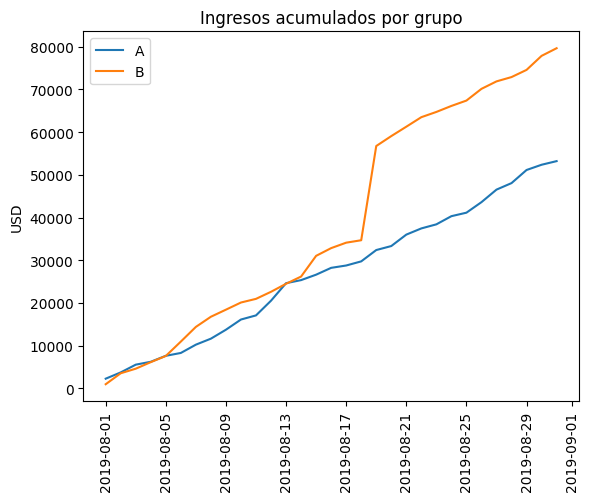

In [ ]:
# TEST A/B
# 1.- Ingreso acumulado por grupo

datesGroups = df_orders[['date', 'group']].drop_duplicates()

df_ordersGroup = datesGroups.apply(lambda x: df_orders[np.logical_and(df_orders['date'] <= x['date'], df_orders['group'] == x['group'])].agg({'date':'max', 'group':'max', 'transaction_id':pd.Series.nunique, 'visitor_id':pd.Series.nunique, 'revenue':'sum'}), axis=1).sort_values(by=['date','group'])
df_visitsGroup = datesGroups.apply(lambda x: df_visits[np.logical_and(df_visits['date'] <= x['date'], df_visits['group'] == x['group'])].agg({'date':'max', 'group':'max', 'visits':'sum'}), axis=1).sort_values(by=['date','group'])

df_data = df_ordersGroup.merge(df_visitsGroup, left_on=['date','group'], right_on=['date', 'group'])

df_data.columns = ['date', 'group', 'orders', 'visitors', 'revenue', 'visits']

df_data['conversion'] = df_data['orders'] / df_data['visitors']

df_dataA = df_data[df_data['group'] =='A'][['date','revenue','orders']]
df_dataB = df_data[df_data['group'] =='B'][['date','revenue','orders']]

#plt.Figure(figsize=(12,6))
#plt.plot(df_dataA['date'], df_dataA['revenue'], label='A')
#plt.plot(df_dataB['date'], df_dataB['revenue'], label='B')
#plt.title('Tamaño de pedido promedio acumulado por grupo')
#plt.xticks(rotation=90)
#plt.ylabel('USD')
#plt.legend()
#plt.show()

### Conclusiones:

Ambos grupos muestran crecimiento constante, pero el grupo B supera claramente a A a partir de la mitad del experimento, alrededor del 18-20 de agosto se observa un salto marcado en B (incremento fuerte de ingresos acumulados), lo que genera una brecha sostenida con respecto a A y que puede deberse a una orden atípicamente grande que empuja el acumulado.

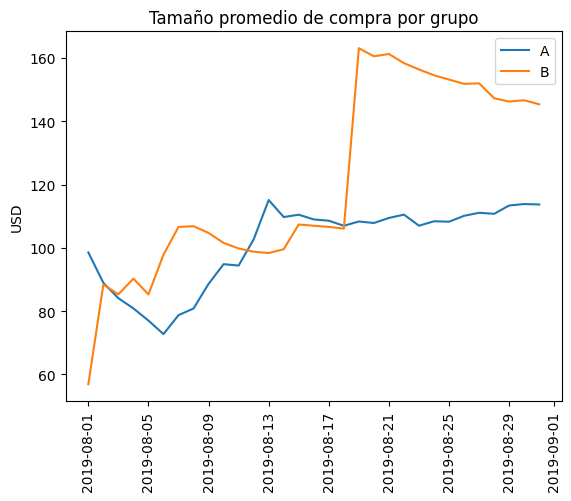

In [ ]:
# TEST A/B
# 2.- Tamaño de pedido promedio acumulado por grupo.

#plt.title('Tamaño promedio de compra por grupo')
#plt.plot(df_dataA['date'], df_dataA['revenue']/df_dataA['orders'], label='A')
#plt.plot(df_dataB['date'], df_dataB['revenue']/df_dataB['orders'], label='B')
#plt.xticks(rotation=90)
#plt.ylabel('USD')
#plt.legend()

### Conclusión: 

Tamaño promedio de compra (AOV) por grupo

Grupo A: se mantiene relativamente estable, alrededor de 100–115 USD después de los primeros días, sin grandes fluctuaciones.

Grupo B: arranca con valores similares, pero a partir del 18 de agosto también da un salto notable, llegando incluso a más de 160 USD. Posteriormente empieza a descender lentamente pero se mantiene siempre por encima de A.

Conjetura: ese comportamiento refuerza la idea de (valores atípicos) pedidos muy grandes en el grupo B, que dispararon temporalmente los valores. Al acumular más datos, el promedio se estabiliza, aunque siempre se conserva más alto que en A.

In [ ]:
# TEST A/B
# 3.- Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el 
#     grupo B en comparación con el grupo A. Elabora conclusiones y conjeturas.
